# Composed vs E2E Inference Profiling

This notebook investigates why composed queued inference is much slower than E2E queued inference, and profiles where the time goes.

Goals:
1. Reproduce FPS gap on a controlled frame subset.
2. Measure per-stage cost inside the composed pipeline.
3. Quantify repeated work and cache impact.
4. Compare composed variants (with and without optional heads).
5. Produce practical optimization recommendations.

In [ ]:
import os
from collections import defaultdict
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from ultralytics import YOLO

import MIREIA.perception.feature_integration as fi_mod
from MIREIA.config import Config
from MIREIA.data_collection.dataset_utils import load_jsonl_records, resolve_image_path
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    FeatureIntegrator,
    QueuedComposedBDUGRURiskInference,
    QueuedE2ERiskInference,
    create_environment_classifier_predictor,
    load_road_segmentation_model,
)
from MIREIA.perception.flow import EgoMotionEstimator, track_objects

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True, precision=4)

print("Imports loaded.")

xFormers not available
xFormers not available


Imports loaded.


In [ ]:
# --- Experiment configuration ---
source_jsonl_name = "dataset.jsonl"
dataset_index = 3
start_frame = 0
profile_num_frames = 120
stage_sample_pairs = 20

scenarios_root = Path(Config.PATH_TO_SCENARIOS)
scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"} and (p / source_jsonl_name).is_file()
]

if not scenario_dirs:
    raise RuntimeError(f"No scenarios with {source_jsonl_name} found under {scenarios_root}")

if dataset_index < 0 or dataset_index >= len(scenario_dirs):
    raise ValueError(f"dataset_index={dataset_index} out of range [0, {len(scenario_dirs) - 1}]")

selected_scenario_dir = scenario_dirs[dataset_index]
records = load_jsonl_records(str(selected_scenario_dir / source_jsonl_name))
if not records:
    raise RuntimeError(f"No records found in {selected_scenario_dir / source_jsonl_name}")

end_frame = min(len(records), start_frame + int(profile_num_frames))
selected_records = records[start_frame:end_frame]
if not selected_records:
    raise RuntimeError("Selected frame range is empty.")

frame_paths = []
frame_ids = []
real_risks = []
for rec in selected_records:
    rel_image = str(rec.get("rgb_image_path", "")).strip()
    if not rel_image:
        continue

    full_path = resolve_image_path(str(selected_scenario_dir), rel_image, normalize_paths=True)
    if not os.path.isfile(full_path):
        continue

    frame_paths.append(full_path)
    frame_ids.append(int(rec.get("frame_id", len(frame_ids))))
    real_risks.append(float(rec.get("ground_truth_risk", 0.0)))

if len(frame_paths) < 4:
    raise RuntimeError("Need at least 4 valid frames for profiling.")

profile_paths = frame_paths
print(f"Selected scenario: {selected_scenario_dir.name}")
print(f"Usable profiling frames: {len(profile_paths)}")

Selected scenario: 01D_ClearNoon_Town02_LowVol
Usable profiling frames: 120


In [ ]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATHS = {
    "e2e_full": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint.pt",
    "bdu_stable": Path(Config.PATH_TO_MODELS) / "bdu_gru_risk_checkpoint_stable.pt",
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
}

required = {
    "e2e_full": MODEL_PATHS["e2e_full"],
    "bdu_stable": MODEL_PATHS["bdu_stable"],
    "yolo": MODEL_PATHS["yolo"],
    "depth": MODEL_PATHS["depth"],
}

missing_required = [f"{name}: {path}" for name, path in required.items() if not path.is_file()]
if missing_required:
    raise FileNotFoundError("Missing required model file(s):\n" + "\n".join(missing_required))

yolo_model = YOLO(str(MODEL_PATHS["yolo"]))
depth_estimator = DepthAnythingV2Estimator(
    checkpoint_path=MODEL_PATHS["depth"],
    encoder="vits",
    device=device_name,
)

environment_predictor = None
if MODEL_PATHS["climate"].is_file():
    environment_predictor = create_environment_classifier_predictor(
        checkpoint_path=str(MODEL_PATHS["climate"]),
        device=device_name,
    )

road_segmentation = None
if MODEL_PATHS["road_seg"].is_file():
    road_segmentation = load_road_segmentation_model(
        checkpoint_path=str(MODEL_PATHS["road_seg"]),
        device=device_name,
    )

feature_integrator = FeatureIntegrator()

e2e_predictor = QueuedE2ERiskInference.from_checkpoint(
    checkpoint_path=str(MODEL_PATHS["e2e_full"]),
    device=device_name,
)

composed_predictor = QueuedComposedBDUGRURiskInference.from_checkpoint(
    checkpoint_path=str(MODEL_PATHS["bdu_stable"]),
    feature_integrator=feature_integrator,
    yolo_model=yolo_model,
    depth_estimator=depth_estimator,
    environment_predictor=environment_predictor,
    road_segmentation=road_segmentation,
    device=device_name,
)

composed_predictor_no_aux = QueuedComposedBDUGRURiskInference.from_checkpoint(
    checkpoint_path=str(MODEL_PATHS["bdu_stable"]),
    feature_integrator=FeatureIntegrator(),
    yolo_model=yolo_model,
    depth_estimator=depth_estimator,
    environment_predictor=None,
    road_segmentation=None,
    device=device_name,
)

print(f"Device: {device_name}")
print("Loaded core models for profiling.")
print("Environment predictor loaded:", environment_predictor is not None)
print("Road segmentation loaded:", road_segmentation is not None)

Device: cuda
Loaded core models for profiling.
Environment predictor loaded: True
Road segmentation loaded: True


## Quick Implementation Audit

Based on the current implementation:

1. The composed queue path computes a pair feature for each step using the previous and current frame.
2. Inside each pair extraction, it runs YOLO tracking twice and depth estimation twice (one per frame).
3. For a sliding window stream, this reprocesses the previous frame repeatedly.
4. Optional environment and road heads also run every step on frame2.
5. A pair-feature cache exists and helps when replaying the same frame sequence, but does not avoid recomputation on first pass for overlapping pairs.

The next cells quantify this with timings and call counts.

In [ ]:
def _run_fps(predictor, frame_paths_local, clear_cache=False):
    predictor.reset_queue()
    if clear_cache and hasattr(predictor, "clear_preprocess_cache"):
        predictor.clear_preprocess_cache()

    per_frame_ms = []
    t0 = perf_counter()
    for path in frame_paths_local:
        t1 = perf_counter()
        predictor.add_image_path(path)
        per_frame_ms.append((perf_counter() - t1) * 1000.0)

    elapsed = perf_counter() - t0
    fps = len(frame_paths_local) / max(elapsed, 1e-9)
    return {
        "elapsed_s": elapsed,
        "fps": fps,
        "mean_frame_ms": float(np.mean(per_frame_ms)),
        "p95_frame_ms": float(np.percentile(per_frame_ms, 95)),
    }


def _load_rgb(path: str) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("RGB"), dtype=np.uint8)


def benchmark_composed_stages(
    frame_paths_local,
    sample_pairs,
    feature_integrator_local,
    yolo_model_local,
    depth_estimator_local,
    environment_predictor_local,
    road_segmentation_local,
):
    pair_count = min(sample_pairs, len(frame_paths_local) - 1)
    if pair_count <= 0:
        raise RuntimeError("Need at least 2 frames for pairwise stage benchmark.")

    frames = [_load_rgb(path) for path in frame_paths_local[: pair_count + 1]]
    ego_estimator = EgoMotionEstimator(crop_ratio=0.9)

    timings = defaultdict(list)

    for i in range(pair_count):
        frame1 = frames[i]
        frame2 = frames[i + 1]

        t = perf_counter()
        tracks1 = track_objects(yolo_model_local, frame1)
        timings["yolo_track_f1"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        tracks2 = track_objects(yolo_model_local, frame2)
        timings["yolo_track_f2"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        depth1 = np.asarray(depth_estimator_local.predict(frame1).depth_map, dtype=np.float32)
        timings["depth_f1"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        depth2 = np.asarray(depth_estimator_local.predict(frame2).depth_map, dtype=np.float32)
        timings["depth_f2"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        bgx, bgy = ego_estimator.estimate_motion(frame1, frame2)
        timings["ego_motion"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        road_rel = feature_integrator_local._infer_road_relative_size(
            frame_rgb=frame2,
            road_segmentation=road_segmentation_local,
        )
        timings["road_seg"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        day_prob, climate_probs = feature_integrator_local._infer_environment_probs(
            frame_rgb=frame2,
            environment_predictor=environment_predictor_local,
        )
        timings["environment"].append((perf_counter() - t) * 1000.0)

        t = perf_counter()
        _ = feature_integrator_local.extract_state_vector(
            yolo_tracks1=tracks1,
            yolo_tracks2=tracks2,
            depth_map1=depth1,
            depth_map2=depth2,
            bg_flow_x=bgx,
            bg_flow_y=bgy,
            road_relative_size=road_rel,
            day_prob=day_prob,
            climate_probs=climate_probs,
        )
        timings["feature_assembly"].append((perf_counter() - t) * 1000.0)

    rows = []
    for stage, values in timings.items():
        arr = np.asarray(values, dtype=np.float64)
        rows.append(
            {
                "stage": stage,
                "mean_ms": float(arr.mean()),
                "median_ms": float(np.median(arr)),
                "p95_ms": float(np.percentile(arr, 95)),
            }
        )

    return pd.DataFrame(rows).sort_values("mean_ms", ascending=False)


def profile_composed_call_counts(predictor, frame_paths_local, clear_cache):
    counters = defaultdict(int)
    timers = defaultdict(float)

    orig_track_objects = fi_mod.track_objects
    orig_depth_predict = predictor.depth_estimator.predict
    orig_extract = predictor.feature_integrator.extract_state_vector_from_sources

    def wrapped_track_objects(*args, **kwargs):
        t = perf_counter()
        out = orig_track_objects(*args, **kwargs)
        timers["track_objects_s"] += perf_counter() - t
        counters["track_objects_calls"] += 1
        return out

    def wrapped_depth_predict(source):
        t = perf_counter()
        out = orig_depth_predict(source)
        timers["depth_predict_s"] += perf_counter() - t
        counters["depth_predict_calls"] += 1
        return out

    def wrapped_extract(*args, **kwargs):
        t = perf_counter()
        out = orig_extract(*args, **kwargs)
        timers["feature_extract_total_s"] += perf_counter() - t
        counters["feature_extract_calls"] += 1
        return out

    fi_mod.track_objects = wrapped_track_objects
    predictor.depth_estimator.predict = wrapped_depth_predict
    predictor.feature_integrator.extract_state_vector_from_sources = wrapped_extract

    try:
        predictor.reset_queue()
        if clear_cache:
            predictor.clear_preprocess_cache()

        per_frame_ms = []
        t0 = perf_counter()
        for path in frame_paths_local:
            t1 = perf_counter()
            _ = predictor.add_image_path(path)
            per_frame_ms.append((perf_counter() - t1) * 1000.0)
        elapsed = perf_counter() - t0
    finally:
        fi_mod.track_objects = orig_track_objects
        predictor.depth_estimator.predict = orig_depth_predict
        predictor.feature_integrator.extract_state_vector_from_sources = orig_extract

    result = {
        "frames": len(frame_paths_local),
        "elapsed_s": float(elapsed),
        "fps": float(len(frame_paths_local) / max(elapsed, 1e-9)),
        "mean_frame_ms": float(np.mean(per_frame_ms)),
        "track_objects_calls": int(counters["track_objects_calls"]),
        "depth_predict_calls": int(counters["depth_predict_calls"]),
        "feature_extract_calls": int(counters["feature_extract_calls"]),
        "track_objects_s": float(timers["track_objects_s"]),
        "depth_predict_s": float(timers["depth_predict_s"]),
        "feature_extract_total_s": float(timers["feature_extract_total_s"]),
    }
    return result

Pair samples profiled: 20


,stage,mean_ms,median_ms,p95_ms
2,depth_f1,36.628410,36.52880,39.833885
3,depth_f2,36.056485,35.76155,41.714385
0,yolo_track_f1,25.310215,20.74215,31.712385
1,yolo_track_f2,21.113085,20.18695,24.777780
5,road_seg,15.308830,14.68440,19.810330
6,environment,14.087880,11.67045,17.339250
4,ego_motion,4.643240,4.58860,5.604705
7,feature_assembly,0.802975,0.74245,1.245175


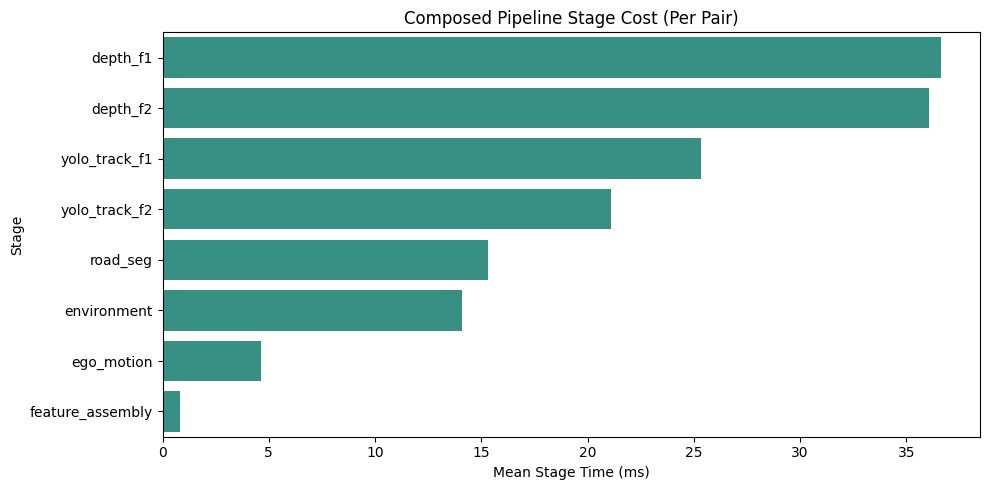

In [ ]:
# Stage-level composed profiling on sample frame pairs
stage_df = benchmark_composed_stages(
    frame_paths_local=profile_paths,
    sample_pairs=stage_sample_pairs,
    feature_integrator_local=feature_integrator,
    yolo_model_local=yolo_model,
    depth_estimator_local=depth_estimator,
    environment_predictor_local=environment_predictor,
    road_segmentation_local=road_segmentation,
)

print(f"Pair samples profiled: {min(stage_sample_pairs, len(profile_paths) - 1)}")
display(stage_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=stage_df, x="mean_ms", y="stage", color="#2a9d8f")
plt.xlabel("Mean Stage Time (ms)")
plt.ylabel("Stage")
plt.title("Composed Pipeline Stage Cost (Per Pair)")
plt.tight_layout()
plt.show()

In [ ]:
# Call-count and cache-impact profiling for composed inference
first_pass = profile_composed_call_counts(
    predictor=composed_predictor,
    frame_paths_local=profile_paths,
    clear_cache=True,
)

second_pass_same_sequence = profile_composed_call_counts(
    predictor=composed_predictor,
    frame_paths_local=profile_paths,
    clear_cache=False,
)

count_df = pd.DataFrame(
    [
        {"pass": "first_pass_cold_cache", **first_pass},
        {"pass": "second_pass_warm_cache", **second_pass_same_sequence},
    ]
)

count_df["track_calls_per_frame"] = count_df["track_objects_calls"] / count_df["frames"]
count_df["depth_calls_per_frame"] = count_df["depth_predict_calls"] / count_df["frames"]
count_df["feature_extract_calls_per_frame"] = count_df["feature_extract_calls"] / count_df["frames"]

display(count_df)

print("\nInterpretation helpers:")
print("- Near 2.0 track/depth calls per frame on cold pass indicates double per-step frame processing.")
print("- Near 0.0 calls on warm pass indicates pair/source cache re-use for repeated sequences.")

,pass,frames,elapsed_s,fps,mean_frame_ms,track_objects_calls,depth_predict_calls,feature_extract_calls,track_objects_s,depth_predict_s,feature_extract_total_s,track_calls_per_frame,depth_calls_per_frame,feature_extract_calls_per_frame
0,first_pass_cold_cache,120,12.379374,9.693544,103.160174,120,120,0,2.411851,4.961069,0.0,1.0,1.0,0.0
1,second_pass_warm_cache,120,0.268189,447.446145,2.234296,0,0,0,0.000000,0.000000,0.0,0.0,0.0,0.0



Interpretation helpers:
- Near 2.0 track/depth calls per frame on cold pass indicates double per-step frame processing.
- Near 0.0 calls on warm pass indicates pair/source cache re-use for repeated sequences.


,pipeline,elapsed_s,fps,mean_frame_ms,p95_frame_ms
2,Composed (warm cache),0.298353,402.207988,2.485523,3.686305
0,E2E,2.237089,53.641138,18.641205,17.870545
3,Composed no env/road (cold),9.252123,12.969996,77.099961,89.468810
1,Composed (cold cache),14.293503,8.395422,119.111312,122.973690


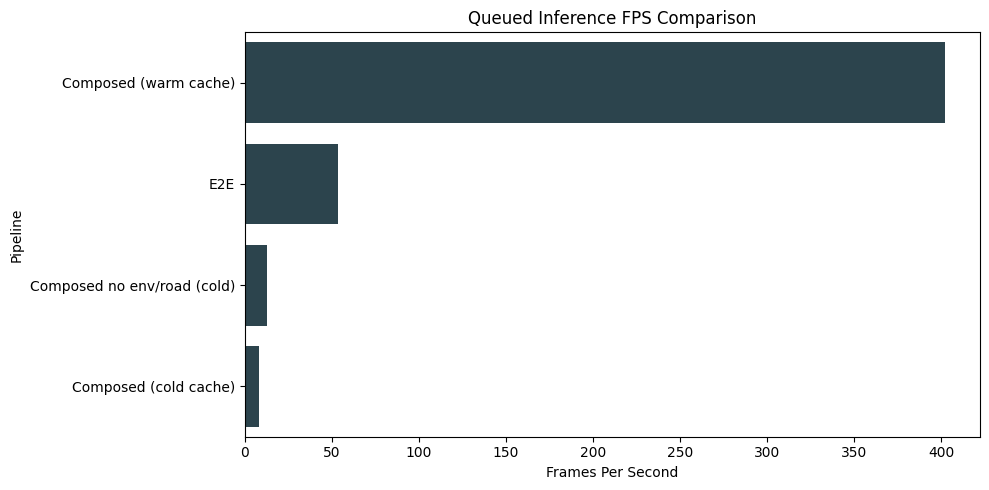

E2E / Composed(cold) speed ratio: 6.39x

Actionable optimization directions:
1. Cache per-frame perception outputs (YOLO tracks + depth map + env + road), then compose pair features from cached frame-level primitives.
2. Keep pair-level cache for replay use-cases, but avoid recomputing previous-frame perception on first pass.
3. Consider lightweight detector/depth backbones for runtime mode, with full models for offline quality runs.
4. Optionally disable environment/road heads when not needed to reduce composed latency.


In [ ]:
# End-to-end FPS comparison and optional-head ablation
bench_rows = []

e2e_stats = _run_fps(e2e_predictor, profile_paths, clear_cache=True)
bench_rows.append({"pipeline": "E2E", **e2e_stats})

composed_cold = _run_fps(composed_predictor, profile_paths, clear_cache=True)
bench_rows.append({"pipeline": "Composed (cold cache)", **composed_cold})

composed_warm = _run_fps(composed_predictor, profile_paths, clear_cache=False)
bench_rows.append({"pipeline": "Composed (warm cache)", **composed_warm})

composed_no_aux = _run_fps(composed_predictor_no_aux, profile_paths, clear_cache=True)
bench_rows.append({"pipeline": "Composed no env/road (cold)", **composed_no_aux})

fps_df = pd.DataFrame(bench_rows).sort_values("fps", ascending=False)
display(fps_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=fps_df, x="fps", y="pipeline", color="#264653")
plt.xlabel("Frames Per Second")
plt.ylabel("Pipeline")
plt.title("Queued Inference FPS Comparison")
plt.tight_layout()
plt.show()

base_composed_fps = float(fps_df.loc[fps_df["pipeline"] == "Composed (cold cache)", "fps"].iloc[0])
base_e2e_fps = float(fps_df.loc[fps_df["pipeline"] == "E2E", "fps"].iloc[0])

print(f"E2E / Composed(cold) speed ratio: {base_e2e_fps / max(base_composed_fps, 1e-9):.2f}x")
print("\nActionable optimization directions:")
print("1. Cache per-frame perception outputs (YOLO tracks + depth map + env + road), then compose pair features from cached frame-level primitives.")
print("2. Keep pair-level cache for replay use-cases, but avoid recomputing previous-frame perception on first pass.")
print("3. Consider lightweight detector/depth backbones for runtime mode, with full models for offline quality runs.")
print("4. Optionally disable environment/road heads when not needed to reduce composed latency.")